# ⬇️ | Imports

In [109]:
import os
import shutil
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support




2 . 

In [ ]:

DATASET_PATH = Path("../dataset")
TRAIN_PATH = DATASET_PATH / "train"
X_PATH = "../X.csv"
y_PATH = "../y.csv"


os.makedirs("../outputs", exist_ok=True)


X = pd.read_csv(X_PATH)
y = pd.read_csv(y_PATH)["target"]

print("Todas as bibliotecas carregadas e caminhos unificados!")
print(f" Dimensões originais do Dataset - X: {X.shape}, y: {y.shape}")

✅ Todas as bibliotecas carregadas e caminhos unificados!
📊 Dimensões originais do Dataset - X: (10901, 23), y: (10901,)


3.

In [ ]:

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.30, 
    random_state=42, 
    stratify=y
)


X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.50, 
    random_state=42, 
    stratify=y_temp
)

print(" Dados divididos de forma Estratificada:")
print(f" Conjunto de Treino (70%): X={X_train.shape}, y={y_train.shape}")
print(f" Conjunto de Validação (15%): X={X_val.shape}, y={y_val.shape}")
print(f" Conjunto de Teste (15%): X={X_test.shape}, y={y_test.shape}")

✂️ Dados divididos de forma Estratificada:
🔹 Conjunto de Treino (70%): X=(7630, 23), y=(7630,)
🔹 Conjunto de Validação (15%): X=(1635, 23), y=(1635,)
🔹 Conjunto de Teste (15%): X=(1636, 23), y=(1636,)


4.

In [ ]:

scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(" Dados normalizados com StandardScaler com sucesso!")

⚖️ Dados normalizados com StandardScaler com sucesso!


5.

In [ ]:


rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)


y_val_pred_rf = rf_model.predict(X_val_scaled)
acc_val_rf = accuracy_score(y_val, y_val_pred_rf)

print("✓ Random Forest treinado com sucesso!")
print(f" Acurácia obtida na Validação: {acc_val_rf * 100:.2f}%")

🌲 Treinando o Modelo 1: Random Forest Classifier...
✓ Random Forest treinado com sucesso!
🎯 Acurácia obtida na Validação: 99.45%


6.

In [ ]:


svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)


y_val_pred_svm = svm_model.predict(X_val_scaled)
acc_val_svm = accuracy_score(y_val, y_val_pred_svm)

print("✓ SVM treinado com sucesso!")
print(f"Acurácia obtida na Validação: {acc_val_svm * 100:.2f}%")

🧠 Treinando o Modelo 2: Support Vector Machine (SVM)...
✓ SVM treinado com sucesso!
🎯 Acurácia obtida na Validação: 94.62%


7. 

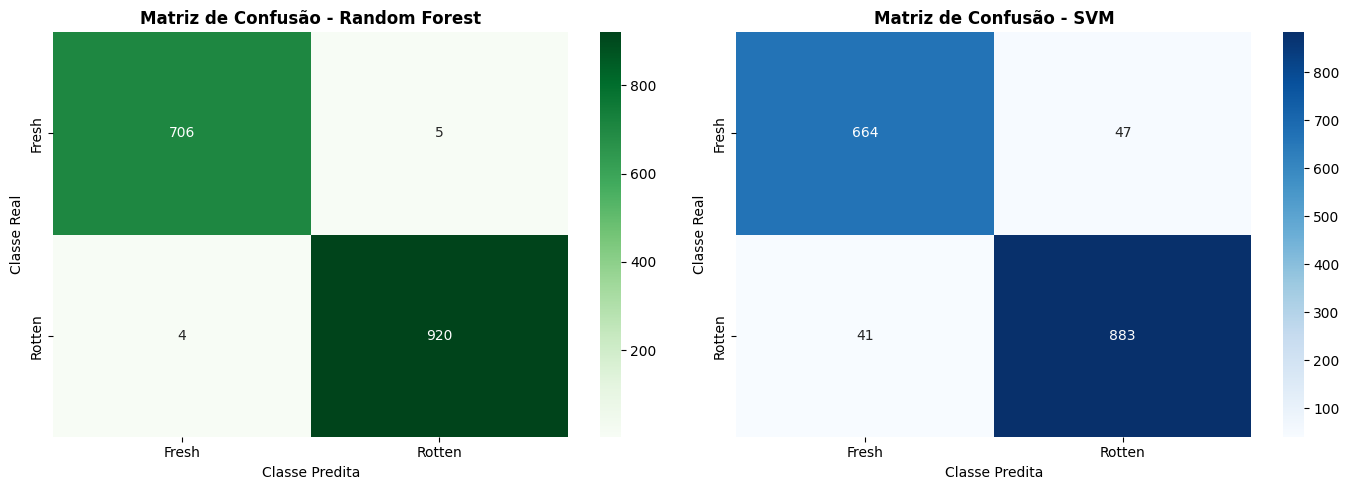

✅ Painel visual das matrizes salvo em: ../outputs/matrizes_confusao_comparadas.png


In [ ]:

cm_rf = confusion_matrix(y_val, y_val_pred_rf)
cm_svm = confusion_matrix(y_val, y_val_pred_svm)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", ax=axes[0],
            xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
axes[0].set_title("Matriz de Confusão - Random Forest", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Classe Real")
axes[0].set_xlabel("Classe Predita")

sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=svm_model.classes_, yticklabels=svm_model.classes_)
axes[1].set_title("Matriz de Confusão - SVM", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Classe Real")
axes[1].set_xlabel("Classe Predita")

plt.tight_layout()
caminho_matrizes = "../outputs/matrizes_confusao_comparadas.png"
plt.savefig(caminho_matrizes, dpi=300)
plt.show()

print(f"Painel visual das matrizes: {caminho_matrizes}")

8.

In [ ]:
def extrair_metricas(y_true, y_pred, acc):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
    return {
        "Accuracy": round(acc, 4),
        "Precision": round(p, 4),
        "Recall": round(r, 4),
        "F1": round(f1, 4)
    }


dados_rf = extrair_metricas(y_val, y_val_pred_rf, acc_val_rf)
dados_svm = extrair_metricas(y_val, y_val_pred_svm, acc_val_svm)


tabela_final = pd.DataFrame([dados_rf, dados_svm], index=["Random Forest", "SVM"])

print("TABELA COMPARATIVA FINAL")
display(tabela_final)

caminho_tabela = "../outputs/tabela_comparativa_modelos.csv"
tabela_final.to_csv(caminho_tabela, index=True)
print(f" Arquivo CSV salvo: {caminho_tabela}")

📊 --- TABELA COMPARATIVA FINAL ---


,Accuracy,Precision,Recall,F1
Random Forest,0.9945,0.9945,0.9943,0.9944
SVM,0.9462,0.9457,0.9448,0.9452


💾 Arquivo CSV salvo com sucesso em: ../outputs/tabela_comparativa_modelos.csv


9.

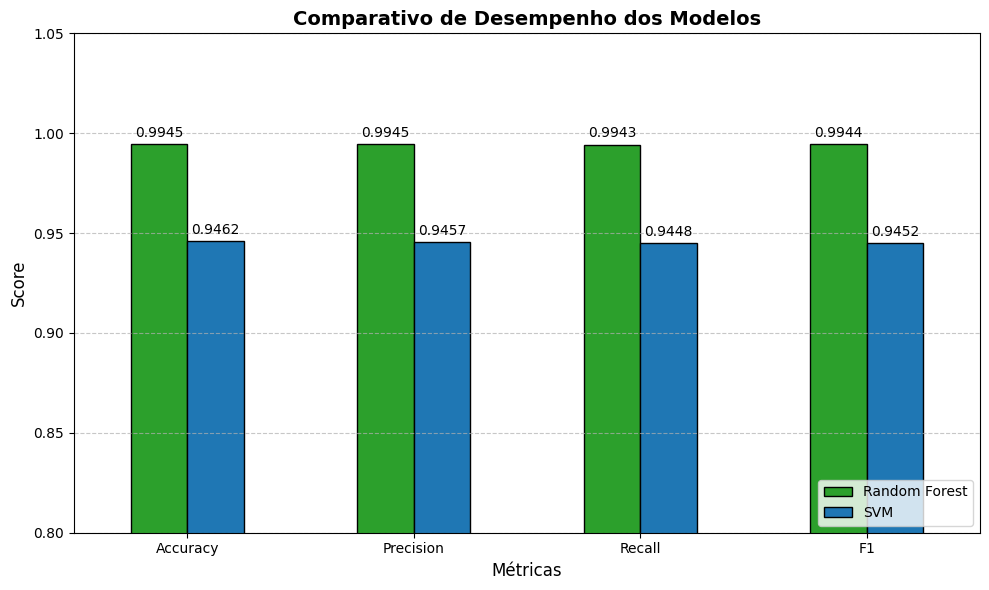


🏁 --- DESEMPENHO NO CONJUNTO DE TESTE ISOLADO (AVALIAÇÃO FINAL) ---
🌲 Random Forest - Acurácia Final: 99.27%
🧠 SVM           - Acurácia Final: 95.42%


In [ ]:

tabela_plot = tabela_final.T
ax = tabela_plot.plot(kind="bar", figsize=(10, 6), color=["#2ca02c", "#1f77b4"], edgecolor="black")

plt.title("Comparativo de Desempenho dos Modelos", fontsize=14, fontweight='bold')
plt.xlabel("Métricas", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.ylim(0.8, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.legend(loc="lower right")

for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3)

plt.tight_layout()
caminho_grafico = "../outputs/grafico_comparativo_modelos.png"
plt.savefig(caminho_grafico, dpi=300)
plt.show()


y_test_pred_rf = rf_model.predict(X_test_scaled)
y_test_pred_svm = svm_model.predict(X_test_scaled)

print("\n DESEMPENHO NO CONJUNTO DE TESTE ISOLADO (AVALIAÇÃO FINAL")
print(f" Random Forest - Acurácia Final: {accuracy_score(y_test, y_test_pred_rf) * 100:.2f}%")
print(f" SVM           - Acurácia Final: {accuracy_score(y_test, y_test_pred_svm) * 100:.2f}%")

10.

In [ ]:
from pathlib import Path
import os
import shutil
import cv2
import numpy as np
from sklearn.model_selection import train_test_split


caminho_teste_1 = Path("../dataset/train")

caminho_teste_2 = Path("dataset/train")

if caminho_teste_1.exists():
    TRAIN_PATH = caminho_teste_1
    PASTA_ERROS = Path("../outputs/imagens_de_erros")
    print(" Pasta dataset encontrada subindo um nível (../dataset/train)")
elif caminho_teste_2.exists():
    TRAIN_PATH = caminho_teste_2
    PASTA_ERROS = Path("outputs/imagens_de_erros")
    print(" Pasta dataset encontrada no mesmo nível (dataset/train)")
else:
    
    raise FileNotFoundError(" Não foi possível encontrar a pasta 'dataset/train' em nenhum dos caminhos padrões. Verifique onde ela está no seu computador!")


reais = np.array(y_val)
preditos = np.array(y_val_pred_rf)
indices_erros = np.where(reais != preditos)[0]

print(f" Identificados {len(indices_erros)} erros do Random Forest na validação.")


lista_caminhos_original = []
for pasta in list(TRAIN_PATH.iterdir()):
    if not pasta.is_dir(): 
        continue
    imagens_pasta = []
    imagens_pasta.extend(list(pasta.glob("*.jpg")))
    imagens_pasta.extend(list(pasta.glob("*.jpeg")))
    imagens_pasta.extend(list(pasta.glob("*.png")))
    for img_path in imagens_pasta:
        img = cv2.imread(str(img_path))
        if img is not None:
            lista_caminhos_original.append(img_path)


_, X_temp_paths, _, _ = train_test_split(lista_caminhos_original, y, test_size=0.30, random_state=42, stratify=y)
_, X_val_paths, _, _ = train_test_split(X_temp_paths, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

os.makedirs(PASTA_ERROS, exist_ok=True)
print(" Copiando imagens que falharam para a pasta de análise")


for idx in indices_erros:
    caminho_original = X_val_paths[idx]
    classe_real = reais[idx]
    classe_predita = preditos[idx]
    
  
    nome_arquivo = f"Real_{classe_real}_Predito_{classe_predita}_{caminho_original.name}"
    destino = os.path.join(PASTA_ERROS, nome_arquivo)
    
    shutil.copy(caminho_original, destino)
    print(f"  Erro isolado: {caminho_original.name} | Real: {classe_real} -> Predito: {classe_predita}")



📁 Pasta dataset encontrada no mesmo nível (dataset/train)
🔍 Identificados 9 erros do Random Forest na validação.
📁 Copiando imagens que falharam para a pasta de análise...
 ❌ Erro isolado: vertical_flip_Screen Shot 2018-06-13 at 12.19.36 AM.png | Real: Fresh -> Predito: Rotten
 ❌ Erro isolado: rotated_by_30_Screen Shot 2018-06-07 at 2.54.41 PM.png | Real: Fresh -> Predito: Rotten
 ❌ Erro isolado: rotated_by_75_Screen Shot 2018-06-12 at 11.42.52 PM.png | Real: Fresh -> Predito: Rotten
 ❌ Erro isolado: rotated_by_45_Screen Shot 2018-06-12 at 11.22.32 PM.png | Real: Rotten -> Predito: Fresh
 ❌ Erro isolado: translation_Screen Shot 2018-06-12 at 8.53.15 PM.png | Real: Rotten -> Predito: Fresh
 ❌ Erro isolado: Screen Shot 2018-06-12 at 11.41.08 PM.png | Real: Fresh -> Predito: Rotten
 ❌ Erro isolado: rotated_by_60_Screen Shot 2018-06-12 at 8.59.44 PM.png | Real: Rotten -> Predito: Fresh
 ❌ Erro isolado: rotated_by_45_Screen Shot 2018-06-07 at 2.46.43 PM.png | Real: Fresh -> Predito: Rotten
